In [1]:
import numpy as np
import sympy
from matplotlib import pyplot as plt
import pandas as pd
from scipy.stats import t
from formulaic import model_matrix
import seaborn as sns
sns.set_theme()

def show_matrix(m: pd.DataFrame, cmap="coolwarm", cbar=False, annot=True, **kwargs):
    axim = sns.heatmap(m.rename(columns=dict(Intercept="I")), cmap=cmap, cbar=cbar, annot=annot, **kwargs)
    axim.xaxis.set_ticks_position("top")
    axim.yaxis.set_ticks_position("right")

# Experiment matrix

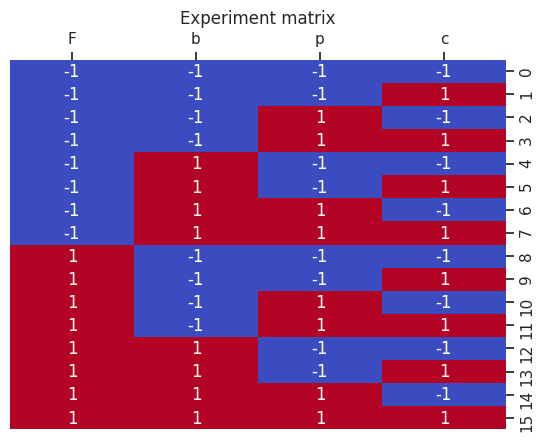

In [2]:
%matplotlib inline
E = pd.read_csv("matrix_experiment_standard.csv").rename(columns=dict(Fr="F"))
show_matrix(E)
plt.title("Experiment matrix")
plt.show()

# Model matrix

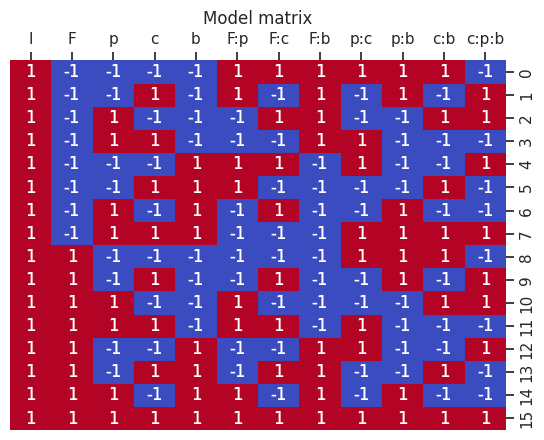

In [3]:
%matplotlib inline
M = model_matrix(
    "F + p + c + b + F:p + F:c + F:b + p:c + p:b + c:b + c:p:b",
    E
).rename(columns=dict(Intercept="I"))
show_matrix(M)
M.to_csv("matrix_model.csv", index=False)

show_matrix(M)
plt.title("Model matrix")
plt.show()

# Results

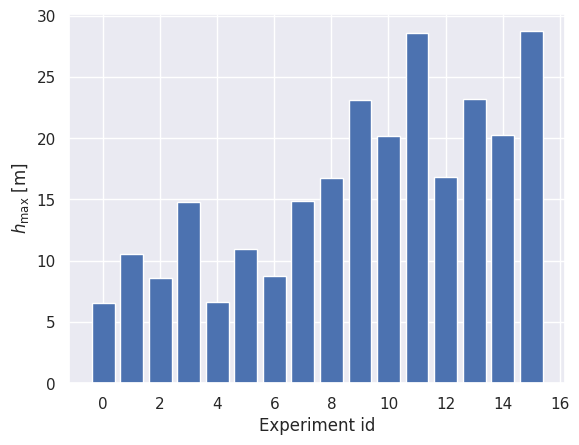

In [4]:
%matplotlib inline
R = np.loadtxt("hmax.csv", delimiter=",")
plt.bar(x=np.arange(R.size), height=R)
plt.xlabel("Experiment id")
plt.ylabel(r"$h_\mathrm{max}$ [m]")
plt.show()

# Effects

In [5]:
def half_effects(M, R):
    Half_effects = np.linalg.solve(M.T @ M, M.T @ R)
    Rel_effects = Half_effects / Half_effects[0]

    beta = 0.95
    alpha = 1-beta
    dof = M.shape[0] - M.shape[1]
    t_student = t.ppf(beta + alpha/2, dof)

    residue = R - M @ Half_effects
    var_exp = residue.T @ residue /(dof)
    D3 = np.linalg.inv(M.T @ M)
    CI = t_student * np.sqrt(np.diag(D3) * var_exp)

    return pd.DataFrame(
        np.vstack((Half_effects.T, CI.T, Rel_effects.T)),
        index=["Half-effects", f"{beta:.0%} CI", "Relative"],
        columns=[f"x_{c.replace(':', '')}" for c in M.columns]
    )

In [6]:
%matplotlib inline
effect_df = half_effects(M, R)

effects = effect_df.iloc[0]
effects.index = effects.index.str.replace(":", "")

display(
  effect_df
  .T
  .round(3)
  .style.background_gradient(cmap="coolwarm", axis="columns")
  .format(precision=3)
)

,Half-effects,95% CI,Relative
x_I,16.199,0.050,1.000
x_F,5.999,0.050,0.370
x_p,1.885,0.050,0.116
x_c,3.132,0.050,0.193
x_b,0.058,0.050,0.004
x_Fp,0.352,0.050,0.022
x_Fc,0.569,0.050,0.035
x_Fb,-0.023,0.050,-0.001
x_pc,0.516,0.050,0.032
x_pb,-0.006,0.050,-0.000


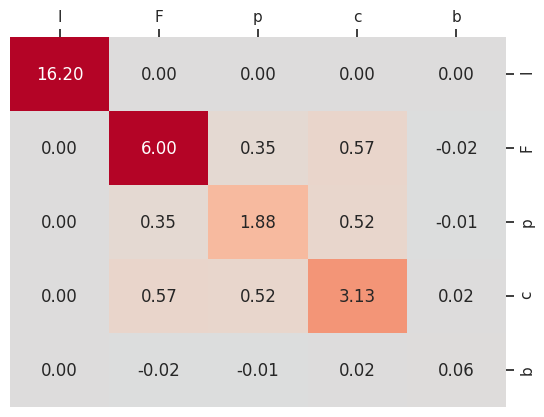

In [7]:
%matplotlib inline

M_main = M[M.columns[~M.columns.str.contains(":")]]

n_main = len(M_main.columns) - 1
effect_matrix = np.zeros((n_main, n_main), dtype=np.float16)

for i, f1 in enumerate(M_main.columns[1:]):
    for j, f2 in enumerate(M_main.columns[i+1:], start=i):
        if f1 == f2:
            f = f"x_{f1}"
        else:
            f = f"x_{f1}{f2}"
        effect_matrix[i, j] = effects[f]
        effect_matrix[j, i] = effects[f]

effect_matrix = np.pad(effect_matrix, ((1, 0), (1, 0)), mode="constant", constant_values=0)
effect_matrix[0, 0] = effects["x_I"]

effect_matrix = pd.DataFrame(effect_matrix, columns=M_main.columns)
vmax = np.abs(effect_matrix.drop(columns="I")).max(axis=None)

show_matrix(effect_matrix, vmin=-vmax, vmax=vmax, yticklabels=M_main.columns, fmt=".2f")
plt.show()

# ANOVA table

In [8]:
from statsmodels.api import stats #For ordinary least square "sm.OLS" 
from statsmodels.formula.api import ols #For ordinary least square "ols" not the same as above 
model = ols("1 ~ F + p + c + b", E)
result = model.fit()
anova_table = stats.anova_lm(result, typ=2)
display(anova_table)

,sum_sq,df,F,PR(>F)
F,2.773339e-32,1.0,0.064453,0.804274
p,4.437343e-31,1.0,1.031250,0.331681
c,1.972152e-31,1.0,0.458333,0.512390
b,3.081488e-33,1.0,0.007161,0.934080
Residual,4.733165e-30,11.0,NaN,NaN


# Predictions

In [9]:
variables = [np.prod([sympy.Symbol(f) for f in k[2:]], initial=1) for k in effects.index]
factors = [sympy.Symbol(k)*v for k, v in zip(effects.index, variables)]

predictor_analytical = sum(factors)
predictor = predictor_analytical.subs(effects.to_dict()).subs(dict(I=1))
predictor_main = predictor_analytical.subs({k: v if len(k)==3 else 0 for k, v in effects.items()}).subs(dict(I=1))

print("### Full expression ###")
print(predictor_analytical)
display(predictor_analytical)
print("### Substituting factors ###")
display(predictor)
print("### Ignoring interactions ###")
display(predictor_main)

### Full expression ###
F*b*x_Fb + F*c*x_Fc + F*p*x_Fp + F*x_F + I*x_I + b*c*p*x_cpb + b*c*x_cb + b*p*x_pb + b*x_b + c*p*x_pc + c*x_c + p*x_p


F*b*x_Fb + F*c*x_Fc + F*p*x_Fp + F*x_F + I*x_I + b*c*p*x_cpb + b*c*x_cb + b*p*x_pb + b*x_b + c*p*x_pc + c*x_c + p*x_p

### Substituting factors ###


-0.0233864687500003*F*b + 0.569278893750001*F*c + 0.35189799375*F*p + 5.99912150625*F - 0.0230145687500005*b*c*p + 0.0236878187500003*b*c - 0.00601165624999989*b*p + 0.0576349062499999*b + 0.516193631249999*c*p + 3.13245386875*c + 1.88512324375*p + 16.19850575625

### Ignoring interactions ###


5.99912150625*F + 0.0576349062499999*b + 3.13245386875*c + 1.88512324375*p + 16.19850575625

## Plotting surfaces and data

In [10]:
n = 100
x, y = np.meshgrid(np.linspace(-1, 1, num=n), np.linspace(-1, 1, num=n))

def regression(debug=False, predictor=predictor, **kwargs):
    variables = [sympy.Symbol(c) for c in E.columns if c not in kwargs]
    p = predictor.subs(kwargs)
    if debug:
        print(variables)
        print(kwargs)
        display(predictor)
        display(p)
    return sympy.lambdify(variables, p)

def regression_main_factors(**kwargs):
    return regression(predictor=predictor_main, **kwargs)

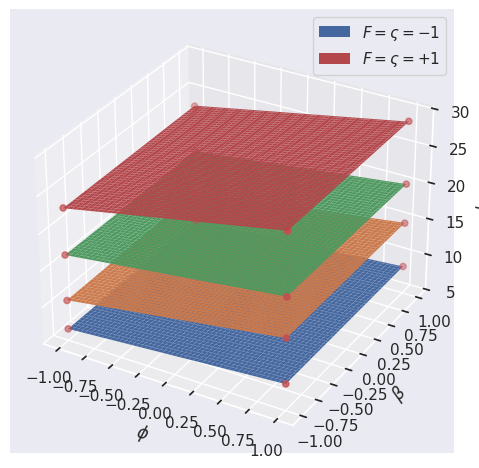

In [11]:
%matplotlib inline
#%matplotlib qt
fig, axes = plt.subplots(subplot_kw=dict(projection="3d"), layout="tight")

axes.plot_surface(x, y, regression(F=-1, c=-1)(p=x, b=y), lw=0, label=r"$F=\varsigma=-1$")
axes.plot_surface(x, y, regression(F=-1, c=+1)(p=x, b=y), lw=0)
axes.plot_surface(x, y, regression(F=+1, c=-1)(p=x, b=y), lw=0)
axes.plot_surface(x, y, regression(F=+1, c=+1)(p=x, b=y), lw=0, label=r"$F=\varsigma=+1$")

axes.scatter(E["p"], E["b"], R, c="r")
axes.set_xlabel(r"$\phi$")
axes.set_ylabel(r"$\beta$")
axes.set_zlabel(r"$h_\mathrm{max}$")
axes.legend()
plt.show()

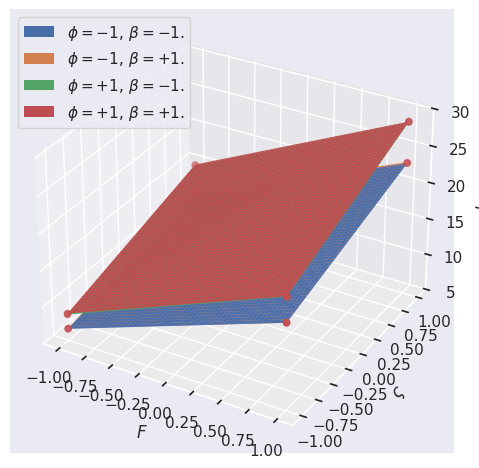

In [12]:
%matplotlib inline
#%matplotlib qt

fig, axes = plt.subplots(subplot_kw=dict(projection="3d"), layout="tight")

axes.plot_surface(x, y, regression(p=-1, b=-1)(F=x, c=y), lw=0, label=r"$\phi=-1,\,\beta=-1.$")
axes.plot_surface(x, y, regression(p=-1, b=+1)(F=x, c=y), lw=0, label=r"$\phi=-1,\,\beta=+1.$")
axes.plot_surface(x, y, regression(p=+1, b=-1)(F=x, c=y), lw=0, label=r"$\phi=+1,\,\beta=-1.$")
axes.plot_surface(x, y, regression(p=+1, b=+1)(F=x, c=y), lw=0, label=r"$\phi=+1,\,\beta=+1.$")

axes.scatter(E["F"], E["c"], R, c="r")
axes.set_xlabel(r"$F$")
axes.set_ylabel(r"$\varsigma$")
axes.set_zlabel(r"$h_\mathrm{max}$")
axes.legend(loc="upper left")
plt.show()

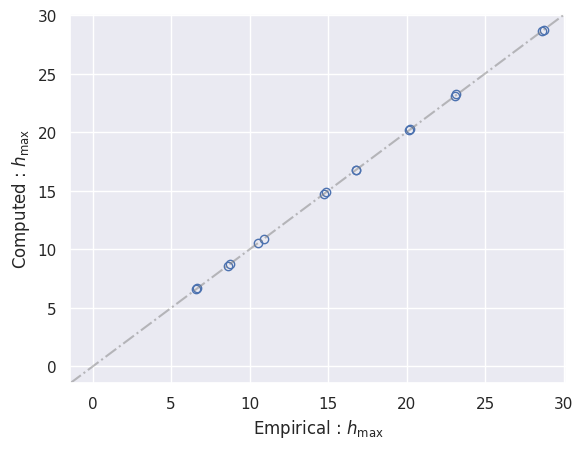

In [15]:
P = regression()(**E)
Pm = regression_main_factors()(**E)

np.savetxt("out.txt", P)

plt.plot(R, P, 'o', mec="C0", mfc="none")
plt.axline((0, 0), slope=1, ls="-.", alpha=0.5, color="gray")
plt.xlabel(r"Empirical : $h_\mathrm{max}$")
plt.ylabel(r"Computed : $h_\mathrm{max}$")
plt.show()

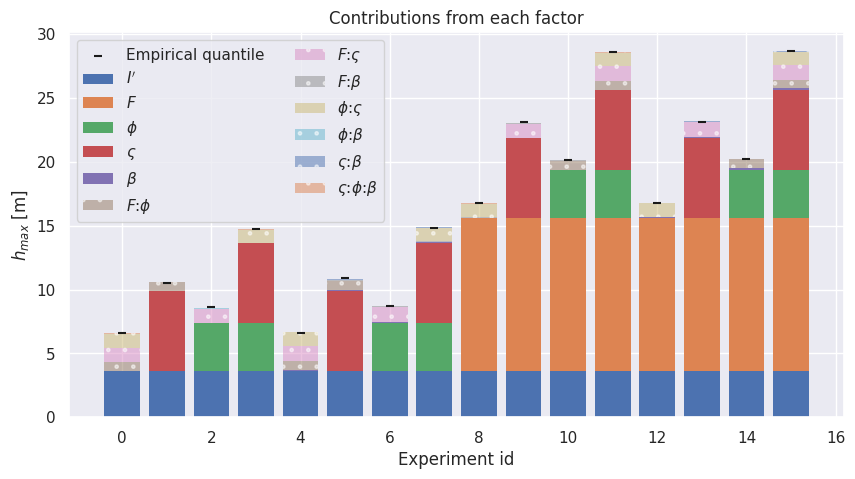

In [14]:
contributions = effects.values*M.values
base_effect = contributions.min(axis=0)
contributions -= base_effect
base_effect = base_effect.sum()
contributions = pd.DataFrame(contributions, columns=M.columns)
labels = dict(I="$I$", F="$F$", p=r"$\phi$", c=r"$\varsigma$", b=r"$\beta$")

plt.figure(figsize=(10, 5))
xa = np.arange(R.size)
plt.scatter(xa, R, zorder=2, label="Empirical quantile", marker="_", c="k")

plt.bar(xa, base_effect, label="$I'$", lw=0)
for i, c in enumerate(M.columns[1:], start=1):
    label = "".join([labels.get(l, ":") for l in c])
    plt.bar(
        xa,
        contributions.values[:, i],
        bottom=base_effect+contributions.values[:, :i].sum(axis=1),
        label=label,
        lw=0,
        alpha=0.5 if ":" in label else 1,
        hatch="." if ":" in label else None
    )

plt.title("Contributions from each factor")
plt.xlabel("Experiment id")
plt.ylabel("$h_{max}$ [m]")
plt.legend(ncols=2)
plt.savefig("contributions.pdf")
plt.show()